Import all the required libraries and load cleaned dataset

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_car_data.csv")

Splitting the data and Z-score normalization

In [11]:
X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (2296, 30)
Testing data shape: (575, 30)


Nueral Network

In [12]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    
    Dense(32, activation='relu'),
    
    Dense(1) 
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='mean_squared_error',
    metrics=['mean_absolute_error'] 
)

print("Starting training...")
history = model.fit(
    X_train_scaled, 
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Starting training...
Epoch 1/100


/Users/mujtabaahmad/Desktop/pakistan-used-car-price-prediction/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 59400509194240.0000 - mean_absolute_error: 4247781.0000 - val_loss: 31032004837376.0000 - val_mean_absolute_error: 3960143.5000
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step - loss: 59333257723904.0000 - mean_absolute_error: 4243646.0000 - val_loss: 30886345048064.0000 - val_mean_absolute_error: 3949710.7500
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 527us/step - loss: 58888959295488.0000 - mean_absolute_error: 4218058.5000 - val_loss: 30250998169600.0000 - val_mean_absolute_error: 3904693.5000
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 526us/step - loss: 57619146342400.0000 - mean_absolute_error: 4144003.7500 - val_loss: 28821929590784.0000 - val_mean_absolute_error: 3801334.7500
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 524us/step - loss: 55168531955712.0000 - mean_absolute_error: 3996301.7500 - val_loss: 26351551643648.0000 - val_mean_absolute_error: 3613102.2500
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 531us/step - loss: 51443402

Graph to visualize what the model predicted versus the target value

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 951us/step
R-squared Score: 0.4874
Mean Absolute Error: 1,351,264.06 PKR


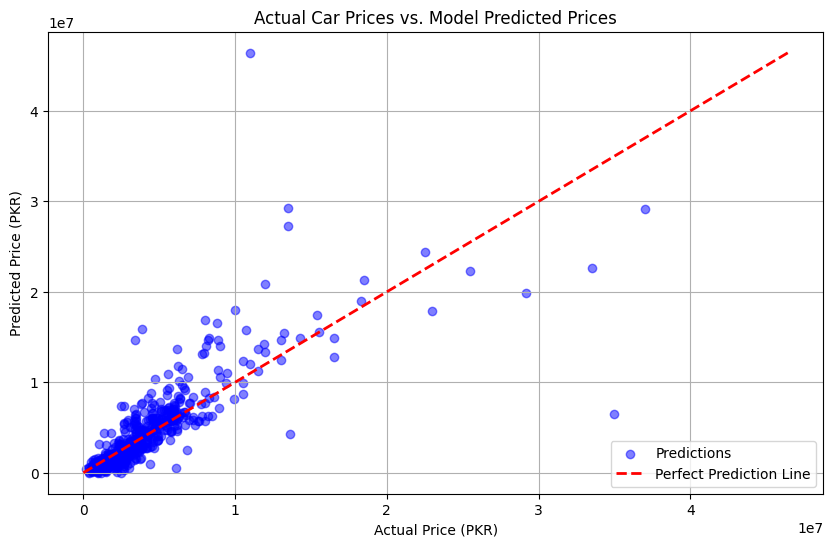

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_scaled)

r_squared = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R-squared Score: {r_squared:.4f}")
print(f"Mean Absolute Error: {mae:,.2f} PKR")

plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.5, color='blue', label='Predictions')

max_price = max(y_test.max(), y_pred.max()) 
min_price = min(y_test.min(), y_pred.min())

plt.plot([min_price, max_price], [min_price, max_price], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')

plt.title('Actual Car Prices vs. Model Predicted Prices')
plt.xlabel('Actual Price (PKR)')
plt.ylabel('Predicted Price (PKR)')
plt.legend()
plt.grid(True)
plt.show()